# HBS pore-radius and pore-pressure distribution from the SCIANTIX moments
author: E.Cappellari, POLIMI-CEA 2026

SCIANTIX carries, for the HBS pores, the mean volume $\bar V$ (radius $R_V=(3\bar V/4\pi)^{1/3}$), the mean Xe atoms per pore $\bar n$ and its variance $\mathrm{Var}(n)$.

The notebook reconstructs classes $(R_i,V_i,w_i,n_i,p_i)$ that reproduce these three moments:

$$\sum_i w_iV_i=\bar V,\qquad \sum_i w_in_i=\bar n,\qquad \sum_i w_i(n_i-\bar n)^2=\mathrm{Var}(n).$$

1. **Pore radius distribution.** Log-normal, $\ln R\sim N(m,s^2)$, 81 classes at $\ln R=m\pm4s$ (K15 Eq. 6; reference $m=-0.5$, $s=0.356$, $r$ in µm), number weights $w_i$. The mean radius is obtained in SCIANTIX from the mean volume from the mean volume $R=0.62035\,V_p^{1/3}$, therefore we need to compare the mean radius to the cube root of the third moment of the distribution, $R_V=e^{m+3s^2/2}$ (K15 Table 1). $\bar V$ fixes $m$ for any $s$, so $R$ is only checked against $\bar V$.

2. **Gas distribution per class.** Two moments of $n$ (mean and variance) do not determine how the gas is shared among the radius classes defined above. The following modelling choice is considered: $$n_i=\bar n\,\frac{R_i^{a}}{\langle R^{a}\rangle}$$where $\bar n$ is the normalisation, $s$ comes from $\mathrm{Var}(n)$ (continuous log-normal: $s=\sigma_{\ln n}/a$, $\sigma_{\ln n}=\sqrt{\ln(1+\mathrm{Var}(n)/\bar n^2)}$, refined on the 81 truncated classes).

3. **Pressure of gas per class redius.** Hard-sphere (Carnahan–Starling) EoS applied to every class: $p_i=\dfrac{n_ik_BT}{V_i}Z(\eta_i)$, $\eta_i=\min(n_iv_{Xe}/V_i,\,0.65)$. The mean pressure will be $\bar p=p_{\rm EoS}(\bar n,\bar V,T)$ (the `HBS pore pressure` of the code used for HBS porosity evolution) and it holds because $\bar n$ and $\bar V$ are conserved.

## Conserved quantities (checked by `check_moments`, tolerance $10^{-8}$)
Classes $i=1\dots N$, number weights $w_i$ ($\sum_iw_i=1$), $V_i=\tfrac43\pi R_i^3$, $n_i$ Xe atoms per pore.

$$\sum_iw_iV_i=\bar V\ \Rightarrow\ R_V=\Big(\sum_iw_iR_i^3\Big)^{1/3}=\Big(\frac{3\bar V}{4\pi}\Big)^{1/3},\qquad
\sum_iw_in_i=\bar n,\qquad
\sum_iw_i(n_i-\bar n)^2=\mathrm{Var}(n)$$

By construction the porosity $\xi=N_p\sum_iw_iV_i=N_p\bar V$, and the pressure of the volume-weighted mean density,

$$\rho_{vol}=\frac{\sum_iw_in_i}{\sum_iw_iV_i}=\frac{\bar n}{\bar V},\qquad
p\big(\rho_{vol}\big)=p_{\rm EoS}(\bar n,\bar V,T)=\bar p,$$

$$p_{\rm EoS}(n,V,T)=\frac{nk_BT}{V}Z(\eta),\quad \eta=\min\!\Big(\frac{nv_{Xe}(T)}{V},\,0.65\Big),\quad Z=\frac{1+\eta+\eta^2-\eta^3}{(1-\eta)^3}.$$

## Rupture per class
Rigid pores at fixed $n_i,V_i$, class $i$ breaks when $p_i\ge P_{cr,i}$ (J19 Eq. 22, instantaneous): the progressive rupture comes from the spread of $p_i$ across the classes, hence from $a$.

K15: K. Kulacsy, J. Nucl. Mater. 466 (2015) 409. J19: L.O. Jernkvist, EPJ Nucl. Sci. Technol. 5 (2019) 11.

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

K_B = 1.380649e-23
GAMMA = 1.1  # (N/m) UO2HBS, SetMatrix.C
ETA_CAP = 0.65  # cap of the hard-sphere packing fraction, HighBurnupStructurePorosity.C
K15_SIGMA = 0.356  # K15 Table 2: sigma_ln r of the reference distribution
N_CLASSES, SPAN = 80, 4.0  # nodes at ln R = m +/- 4 s, as option 2 of HighBurnupStructureFragmentation.C


def xe_volume(T):
    """Volume of a Xe atom, v = pi/6 d^3, d(T) as in HighBurnupStructurePorosity.C."""
    d = 4.45e-10 * (0.8542 - 0.03996 * np.log(T / 231.2))
    return np.pi / 6.0 * d**3


def Z(eta):
    """Carnahan-Starling compressibility factor p V / (n k T)."""
    return (1 + eta + eta**2 - eta**3) / (1 - eta) ** 3


def pore_pressure(n, V, T):
    """Gas pressure of pores holding n atoms in the volume V (vectorised), hard-sphere EoS with eta <= 0.65."""
    return n * K_B * T * Z(np.minimum(n * xe_volume(T) / V, ETA_CAP)) / V


def classes(R_V, s):  # TBC
    """Radius classes of the log-normal pore-size distribution K15 Eq. 6, discretised.

    Input : R_V = (3 V / 4 pi)^(1/3), the radius of the mean pore volume (the SCIANTIX 'HBS pore radius');
            s   = sigma of ln R (width of the distribution, 0 = all pores equal).
    Output: R (m), V = 4/3 pi R^3 (m3) and the number weights w of the N_CLASSES classes, sum(w) = 1.

    Nodes: ln R_i = const + s x_i, with x_i equally spaced in [-SPAN, SPAN]; the weight of the class is the Gaussian in x,
    w_i ~ exp(-x_i^2 / 2). The tails beyond +/- SPAN * s are dropped.
    Scale: the constant is chosen so that the third moment is exact on the nodes, sum(w R^3)^(1/3) = R_V
    (K15 Table 1: mean radius from the mean pore volume), i.e. sum(w V) = V_mean for any s.
    """
    x = np.linspace(-SPAN, SPAN, N_CLASSES) if s > 0 else np.zeros(1)   # node coordinates, in units of s
    w = np.exp(-0.5 * x**2)                                               # Gaussian weight in x = ln R
    w /= w.sum()
    g = np.exp(s * x)                                                     # R_i up to a common factor
    R = R_V * g / np.cbrt(np.sum(w * g**3))                               # common factor for normalisation: sum(w R^3)^(1/3) = R_V
    return R, 4.0 / 3.0 * np.pi * R**3, w


def build(R_V, n_mean, var_n, T, a):
    """Classes with n_i = n_mean R_i^a / <R^a>; s from Var(n): the continuous log-normal value sigma_lnn / a is refined
    on the 81 truncated nodes. V (through R_V), n and Var(n) hold on the classes; p_i is the EoS of every class."""
    def nodes(s):
        R, V, w = classes(R_V, s)
        return R, V, w, n_mean * R**a / np.sum(w * R**a)

    s0 = np.sqrt(np.log(1.0 + var_n / n_mean**2)) / a
    var_err = lambda s: np.sum(nodes(s)[2] * (nodes(s)[3] - n_mean) ** 2) / var_n - 1.0
    s = brentq(var_err, 0.5 * s0, 2.0 * s0, xtol=1e-13)
    R, V, w, n_i = nodes(s)
    return {"R": R, "V": V, "w": w, "n": n_i, "p": pore_pressure(n_i, V, T), "sigma": s, "mu": np.log(R_V) - 1.5 * s**2, "a": a}


def moments(d):
    """Number-weighted moments of the classes: V, R_V (cube root of <R^3>), n, Var(n), <p>."""
    w = d["w"]
    return {"V": np.sum(w * d["V"]), "R_V": np.cbrt(np.sum(w * d["R"] ** 3)),
            "n": np.sum(w * d["n"]), "var_n": np.sum(w * (d["n"] - np.sum(w * d["n"])) ** 2),
            "p_mean": np.sum(w * d["p"])}


def check_moments(d, V, n, var_n, tol=1e-8):
    """Relative error of the three conserved moments; raises if one exceeds tol."""
    m = moments(d)
    err = {"V": abs(m["V"] / V - 1.0), "n": abs(m["n"] / n - 1.0), "var_n": abs(m["var_n"] / var_n - 1.0)}
    bad = [k for k, e in err.items() if e > tol]
    if bad:
        raise AssertionError(f"moments not conserved (relative error > {tol}): " + ", ".join(f"{k} {err[k]:.2e}" for k in bad))
    return err


### Inputs and tests to check conserved quantities

In [79]:
R_in = 0.35e-6                        # (m) mean pore radius, only checked against V
V_in = 4.0 / 3.0 * np.pi * R_in**3    # (m3) mean pore volume
T    = 800.0                          # (K)
Ph   = 70.0e6                         # (Pa), positive in compression
a    = 2.5                            # exponent of the closure n_i ~ R_i^a - TBC

# Test moments of n, not a SCIANTIX state: n_in is a value of the order of the NFIR end of base irradiation and var_in is
# the one of the K15 reference width (s = 0.356) with the closure n_i ~ R_i^a, so that the solution is known.
# Replace n_in and var_in with the SCIANTIX values ('Xe atoms per HBS pore' and its variance in output.txt) to use the notebook.
n_in = 1.4531e9
R_t, V_t, w_t = classes((3 * V_in / (4 * np.pi)) ** (1 / 3), K15_SIGMA)
n_t = n_in * R_t**a / np.sum(w_t * R_t**a)
var_in = np.sum(w_t * (n_t - n_in) ** 2)
print(f"n = {n_in:.4e},  Var(n) = {var_in:.4e}")

R_V = (3.0 * V_in / (4.0 * np.pi)) ** (1.0 / 3.0)
if abs(R_V / R_in - 1.0) > 1e-3:
    print(f"warning: R = {R_in:.4e} m differs from (3V/4pi)^(1/3) = {R_V:.4e} m; V is used")

d = build(R_V, n_in, var_in, T, a)
m = moments(d)
err = check_moments(d, V_in, n_in, var_in)   # raises if a moment is off by more than 1e-8

print(f"sigma_lnR = {d['sigma']:.4f} (K15 reference {K15_SIGMA}), median = {np.exp(d['mu']) * 1e6:.4f} um")
print(f"{'':8s}{'target':>14s}{'distribution':>16s}{'rel. err.':>12s}")
for name, key, target, got in (("V (m3)", "V", V_in, m["V"]), ("n", "n", n_in, m["n"]), ("Var(n)", "var_n", var_in, m["var_n"])):
    print(f"{name:8s}{target:14.5e}{got:16.5e}{err[key]:12.1e}")
print(f"R_V = {m['R_V'] * 1e6:.4f} um (input {R_V * 1e6:.4f} um), <p> = {m['p_mean'] / 1e6:.1f} MPa")

n = 1.4531e+09,  Var(n) = 2.5039e+18
sigma_lnR = 0.3560 (K15 reference 0.356), median = 0.2894 um
                target    distribution   rel. err.
V (m3)     1.79594e-19     1.79594e-19     2.2e-15
n          1.45310e+09     1.45310e+09     0.0e+00
Var(n)     2.50388e+18     2.50388e+18     0.0e+00
R_V = 0.3500 um (input 0.3500 um), <p> = 329.6 MPa


### Truncation of the log-normal tails
The continuous log-normal has an infinite tail towards large radii. The classes cover $\ln R_i=m+s\,x_i$, $x_i\in[-4,4]$ (81 equally spaced nodes) and the weights $w_i\propto e^{-x_i^2/2}$ are renormalised on this grid: the tail beyond $\pm4s$ is dropped. 

**Mass left outside $\pm4s$.** A quantity weighted by $R^k$ ($k=0$ number, $k=3$ volume, $k=a$ gas, $k=2a$ the second moment of $n$) is again Gaussian in $x$ with the mean shifted to $ks$, so the fraction outside is
$$f_k=\Phi(-4-ks)+\big[1-\Phi(4-ks)\big],$$
$\Phi$ the standard normal cdf. The upper tail dominates and grows with $k$: the heavier the weight on the large pores, the more the cut matters. $\mathrm{Var}(n)$ weighs $n^2\propto R^{2a}$, the most sensitive of the three moments; this is why $s$ is refined on the 81 nodes instead of being taken from the continuous formula.

In [80]:
from scipy.special import ndtr   # standard normal cdf

s_ = d["sigma"]
print(f"s = {s_:.4f}, R_min = {np.exp(d['mu'] - SPAN * s_) * 1e6:.3f} um, R_max = {np.exp(d['mu'] + SPAN * s_) * 1e6:.3f} um (mu + 3s: {np.exp(d['mu'] + 3 * s_) * 1e6:.3f} um, K15 Table 1)")
print(f"{'weight':26s}{'k':>6s}{'below -4s':>12s}{'above +4s':>12s}{'outside':>12s}")
for name, k in (("number", 0.0), ("volume", 3.0), ("gas n ~ R^a", a), ("n^2 ~ R^(2a)  (Var n)", 2.0 * a)):
    lo, hi = ndtr(-SPAN - k * s_), 1.0 - ndtr(SPAN - k * s_)
    print(f"{name:26s}{k:6.2f}{lo:12.2e}{hi:12.2e}{lo + hi:12.2e}")

s = 0.3560, R_min = 0.070 um, R_max = 1.202 um (mu + 3s: 0.842 um, K15 Table 1)
weight                         k   below -4s   above +4s     outside
number                      0.00    3.17e-05    3.17e-05    6.33e-05
volume                      3.00    2.01e-07    1.68e-03    1.68e-03
gas n ~ R^a                 2.50    5.04e-07    9.35e-04    9.36e-04
n^2 ~ R^(2a)  (Var n)       5.00    3.74e-09    1.32e-02    1.32e-02


### Distributions

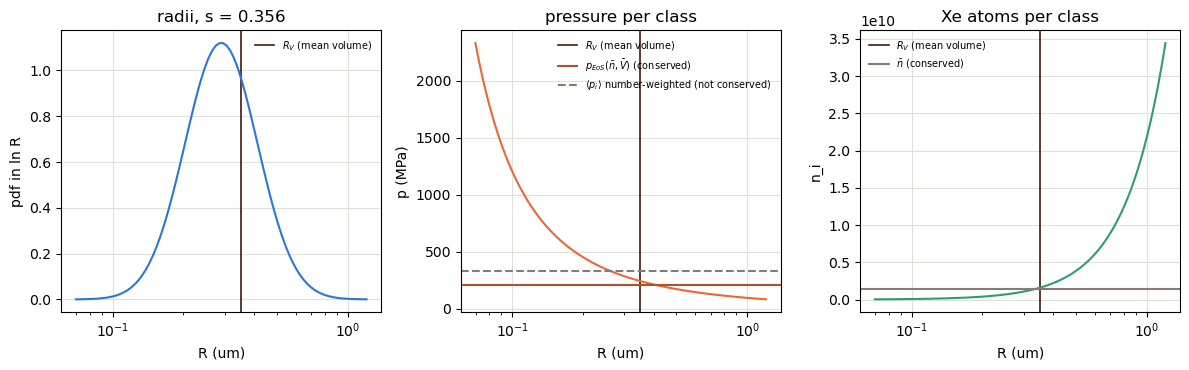

In [81]:
R_um = d["R"] * 1e6
pdf  = d["w"] / np.gradient(np.log(d["R"])) if len(R_um) > 1 else d["w"]    # pdf of ln R: integrates to 1 over ln R
p_eos = float(pore_pressure(m["n"], m["V"], T)) / 1e6                       # EoS of the mean quantities, conserved

fig, ax = plt.subplots(1, 3, figsize=(12, 3.8))
for ax_ in ax:
    ax_.set_xscale("log")                                                   # R spans a decade and a half: log axis
    ax_.axvline(m["R_V"] * 1e6, color="#3e1c0f", lw=1.2, label=r"$R_V$ (mean volume)")

ax[0].plot(R_um, pdf, color="#2a78d6")
ax[0].set(xlabel="R (um)", ylabel="pdf in ln R", title=f"radii, s = {d['sigma']:.3f}")

ax[1].plot(R_um, d["p"] / 1e6, color="#eb6834")
ax[1].axhline(p_eos, color="#ab522f", label=r"$p_{EoS}(\bar n,\bar V)$ (conserved)")
ax[1].axhline(m["p_mean"] / 1e6, color="#887B75", ls="--", label=r"$\langle p_i\rangle$ number-weighted (not conserved)")
ax[1].set(xlabel="R (um)", ylabel="p (MPa)", title="pressure per class")

ax[2].plot(R_um, d["n"], color="#2f9e6e")
ax[2].axhline(m["n"], color="#887B75", label=r"$\bar n$ (conserved)")
ax[2].set(xlabel="R (um)", ylabel="n_i", title="Xe atoms per class")

for ax_ in ax:
    ax_.grid(True, color="#e1e0d9")
    ax_.legend(frameon=False, fontsize=7)
fig.tight_layout()
plt.show()

Each moment is a sum over the classes, so it can be shown as the cumulative contribution of the classes up to the radius $R$:

$$\frac{\sum_{R_i\le R}w_iV_i}{\bar V},\qquad
\frac{\sum_{R_i\le R}w_in_i}{\bar n},\qquad
\frac{\sum_{R_i\le R}w_i(n_i-\bar n)^2}{\mathrm{Var}(n)}.$$

All three must end at exactly 1 at the largest class. The curves also show **which pores carry each moment**: the number weights $w_i$ are concentrated near the median, but the volume, the gas and above all the variance come from the large pores, so the right tail matters more for $\mathrm{Var}(n)$ than for the number of pores.

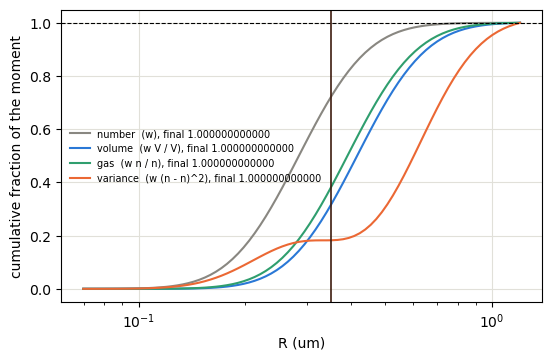

number  (w)                carried by the classes with R <= R_V: 0.694
volume  (w V / V)          carried by the classes with R <= R_V: 0.287
gas  (w n / n)             carried by the classes with R <= R_V: 0.351
variance  (w (n - n)^2)    carried by the classes with R <= R_V: 0.182
each class sum equals its target (V, n, Var(n), number): ok


In [82]:
w_, V_, n_, R_ = d["w"], d["V"], d["n"], d["R"]
contrib = {
    "number  (w)":              (w_, 1.0),
    "volume  (w V / V)":        (w_ * V_, V_in),
    "gas  (w n / n)":           (w_ * n_, n_in),
    "variance  (w (n - n)^2)":  (w_ * (n_ - n_in) ** 2, var_in),
}
fig, ax = plt.subplots(figsize=(6.2, 3.8))
for (name, (term, target)), color in zip(contrib.items(), ("#898781", "#2a78d6", "#2f9e6e", "#eb6834")):
    cum = np.cumsum(term) / target
    ax.semilogx(R_ * 1e6, cum, color=color, label=f"{name}, final {cum[-1]:.12f}")
ax.axhline(1.0, color="k", lw=0.8, ls="--")
ax.axvline(R_V * 1e6, color="#3e1c0f", lw=1.2)
ax.set(xlabel="R (um)", ylabel="cumulative fraction of the moment")
ax.grid(True, color="#e1e0d9")
ax.legend(frameon=False, fontsize=7, loc="center left")
plt.show()
for name, (term, target) in contrib.items():
    assert abs(np.sum(term) / target - 1.0) < 1e-8, name
R_cut = R_ <= R_V
for name, (term, target) in contrib.items():
    print(f"{name:26s} carried by the classes with R <= R_V: {np.sum(term[R_cut]) / target:.3f}")
print("each class sum equals its target (V, n, Var(n), number): ok")

### Mean pressure and what is conserved
The mean pore pressure is the EoS of the mean quantities, $\bar p=p_{\rm EoS}(\bar n,\bar V,T)$ (the `HBS pore pressure` of the code). It holds because $\bar n$ and $\bar V$ are conserved: it is the pressure of the **volume-weighted mean density** $\rho_{vol}=\sum w_in_i/\sum w_iV_i=\bar n/\bar V$.
The number-weighted mean $\langle p_i\rangle$ is not conserved, and cannot be together with $\bar n$ and $\bar V$ when the pressure is higher in the small pores. For any closure
$$\langle\rho\rangle=\frac{\bar n}{\bar V}-\frac{\mathrm{Cov}(\rho,V)}{\bar V},\qquad \rho_i=\frac{n_i}{V_i},$$
and $\mathrm{Cov}(\rho,V)<0$ when $\rho$ falls with $V$; with $p(\rho)$ convex, $\langle p_i\rangle>\bar p$. Imposing $\langle p_i\rangle=\bar p$ forces $\mathrm{Cov}=0$, a uniform pressure.

In [85]:
p_bar = float(pore_pressure(n_in, V_in, T))
w, Vi, ni, pi = d["w"], d["V"], d["n"], d["p"]
print(f"p_EoS(n, V, T) = {p_bar / 1e6:.1f} MPa   (eta = {n_in * xe_volume(T) / V_in:.3f})")
for name, wt in (("number-weighted", w), ("volume-weighted", w * Vi), ("gas-weighted", w * ni)):
    print(f"<p>, {name:16s}: {np.sum(wt * pi) / np.sum(wt) / 1e6:7.1f} MPa")
print(f"p of the class with R = R_V     : {np.interp(R_V, d['R'], pi) / 1e6:7.1f} MPa")
print(f"mean density, volume-weighted rho = {np.sum(w * ni) / np.sum(w * Vi):.4e} atoms/m3 vs n/V = {n_in / V_in:.4e}")

# What is conserved: the pressure of the volume-weighted mean density, rho_vol = sum w n / sum w V = n / V.
# What is not: the number-weighted <p_i>. Identity, for any closure: <rho> = n / V - Cov(rho, V) / V.
rho_i = ni / Vi
rho_vol = np.sum(w * ni) / np.sum(w * Vi)
p_rho_vol = float(pore_pressure(rho_vol * 1.0, 1.0, T))     # EoS at the density rho_vol (V = 1 m3, n = rho_vol atoms)
cov = np.sum(w * rho_i * Vi) - np.sum(w * rho_i) * np.sum(w * Vi)
print(f"p(rho_vol) = {p_rho_vol / 1e6:.3f} MPa  vs  p_EoS(n, V, T) = {p_bar / 1e6:.3f} MPa   (rel. err. {abs(p_rho_vol / p_bar - 1):.1e})")
print(f"<rho> = {np.sum(w * rho_i):.4e},  n/V - Cov(rho, V)/V = {n_in / V_in - cov / V_in:.4e},  Cov(rho, V)/V = {cov / V_in:.3e}  (< 0: higher density in the small pores)")

p_EoS(n, V, T) = 209.4 MPa   (eta = 0.194)
<p>, number-weighted :   329.6 MPa
<p>, volume-weighted :   219.8 MPa
<p>, gas-weighted    :   234.2 MPa
p of the class with R = R_V     :   244.7 MPa
mean density, volume-weighted rho = 8.0910e+27 atoms/m3 vs n/V = 8.0910e+27
p(rho_vol) = 209.416 MPa  vs  p_EoS(n, V, T) = 209.416 MPa   (rel. err. 4.0e-15)
<rho> = 9.7787e+27,  n/V - Cov(rho, V)/V = 9.7787e+27,  Cov(rho, V)/V = -1.688e+27  (< 0: higher density in the small pores)


### Sensitivity to the closure exponent $a$
Same moments, different $a$, $a=3$ is a uniform pressure.

    a  sigma_lnR    p_min    p_max  <p>_vol   (MPa)   V, n, Var(n) rel. err.
 3.00     0.2967    209.4    209.4    209.4   2e-15 0e+00 2e-16
 2.75     0.3236    133.7    501.3    211.4   2e-15 0e+00 0e+00
 2.50     0.3560     84.2   2331.6    219.8   2e-15 0e+00 0e+00


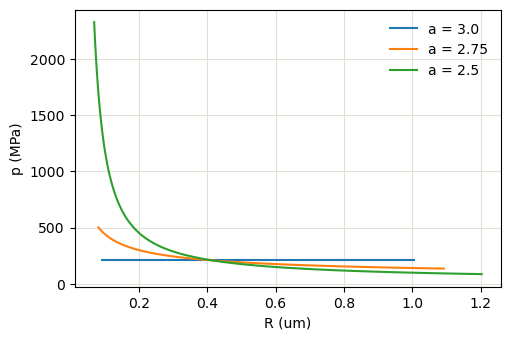

In [86]:
print(f"{'a':>5s}{'sigma_lnR':>11s}{'p_min':>9s}{'p_max':>9s}{'<p>_vol':>9s}   (MPa)   V, n, Var(n) rel. err.")
fig, ax = plt.subplots(figsize=(5.5, 3.6))
for a_ in (3.0, 2.75, 2.5):
    dp = build(R_V, n_in, var_in, T, a_)
    e = check_moments(dp, V_in, n_in, var_in)
    pv = np.sum(dp["w"] * dp["V"] * dp["p"]) / np.sum(dp["w"] * dp["V"]) / 1e6
    print(f"{a_:5.2f}{dp['sigma']:11.4f}{dp['p'].min() / 1e6:9.1f}{dp['p'].max() / 1e6:9.1f}{pv:9.1f}   {e['V']:.0e} {e['n']:.0e} {e['var_n']:.0e}")
    ax.plot(dp["R"] * 1e6, dp["p"] / 1e6, label=f"a = {a_}")
ax.set(xlabel="R (um)", ylabel="p (MPa)")
ax.grid(True, color="#e1e0d9")
ax.legend(frameon=False)
plt.show()

## Check of the conserved moments
**Distributions.** For each $a$, the number-weighted distributions of $V_i$ and $n_i$ on the classes, with the target mean $\bar V$, $\bar n$ (solid) and the mean of the classes (dashed) on top of each other, and the target $\bar n+\sqrt{\mathrm{Var}(n)}$ against the same quantity of the classes (log axis, so the lower edge $\bar n-\sqrt{\mathrm{Var}(n)}$, negative for $\mathrm{CV}_n>1$, is not drawn).
The two must coincide: the mean lines because $\bar V$, $\bar n$ are conserved, the standard deviation because $\mathrm{Var}(n)$ is.

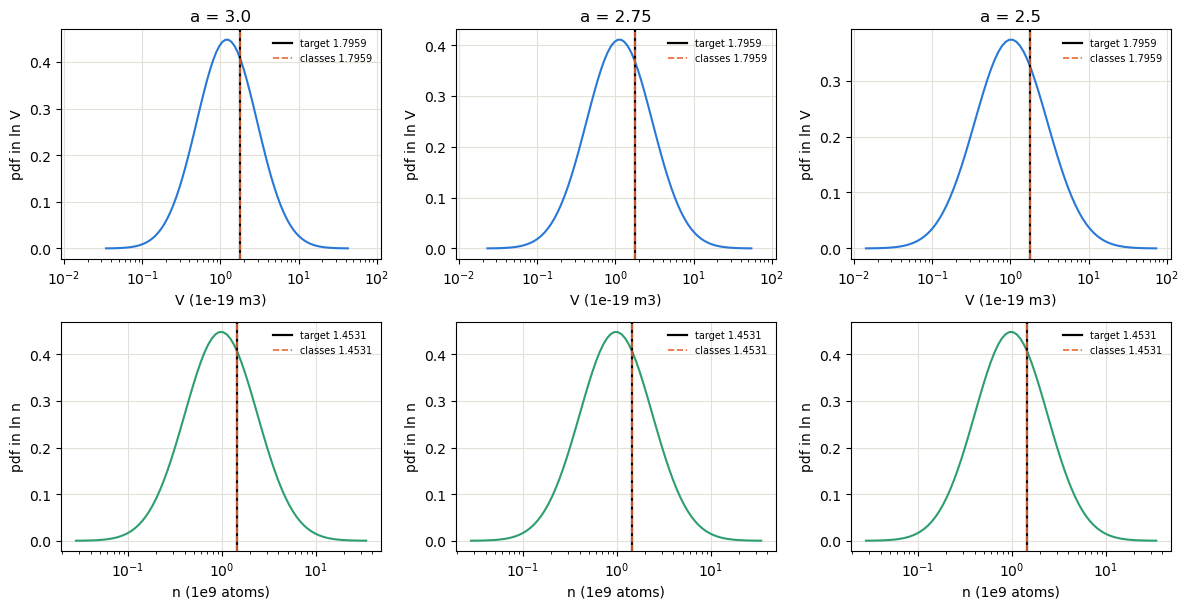

In [87]:
fig, ax = plt.subplots(2, 3, figsize=(12, 6.2), sharex="row")
for ax_ in ax.ravel():
    ax_.set_xscale("log")
for j, a_ in enumerate((3.0, 2.75, 2.5)):
    dp = build(R_V, n_in, var_in, T, a_)
    mp = moments(dp)
    w_, V_, n_ = dp["w"], dp["V"], dp["n"]
    sd_t, sd_c = np.sqrt(var_in), np.sqrt(mp["var_n"])

    # volume: pdf in ln V (ln V = 3 ln R + const) and the mean
    ax[0, j].plot(V_ * 1e19, w_ / np.gradient(np.log(V_)), color="#2a78d6")
    ax[0, j].axvline(V_in * 1e19, color="k", lw=1.6, label=f"target {V_in * 1e19:.4f}")
    ax[0, j].axvline(mp["V"] * 1e19, color="#eb6834", lw=1.2, ls="--", label=f"classes {mp['V'] * 1e19:.4f}")
    ax[0, j].set(title=f"a = {a_}", xlabel="V (1e-19 m3)", ylabel="pdf in ln V")
    ax[0, j].legend(frameon=False, fontsize=7)

    # gas: pdf in ln n, the mean and the +/- one standard deviation bands
    ax[1, j].plot(n_ / 1e9, w_ / np.gradient(np.log(n_)), color="#2f9e6e")
    ax[1, j].axvline(n_in / 1e9, color="k", lw=1.6, label=f"target {n_in / 1e9:.4f}")
    ax[1, j].axvline(mp["n"] / 1e9, color="#eb6834", lw=1.2, ls="--", label=f"classes {mp['n'] / 1e9:.4f}")
    # mean + one standard deviation (the lower edge mean - sd is negative for CV_n > 1 and cannot be drawn on a log axis)
    ax[1, j].set(xlabel="n (1e9 atoms)", ylabel="pdf in ln n")
    ax[1, j].legend(frameon=False, fontsize=7)
for ax_ in ax.ravel():
    ax_.grid(True, color="#e1e0d9")
fig.tight_layout()
plt.show()

The relative error of $\bar V$, $\bar n$, $\mathrm{Var}(n)$ against the exponent $a$ (at the test inputs), against the coefficient of variation $\mathrm{CV}_n=\sqrt{\mathrm{Var}(n)}/\bar n$ and against the mean gas $\bar n$ (at $a=2.5$). The dashed line is the tolerance of `check_moments`.

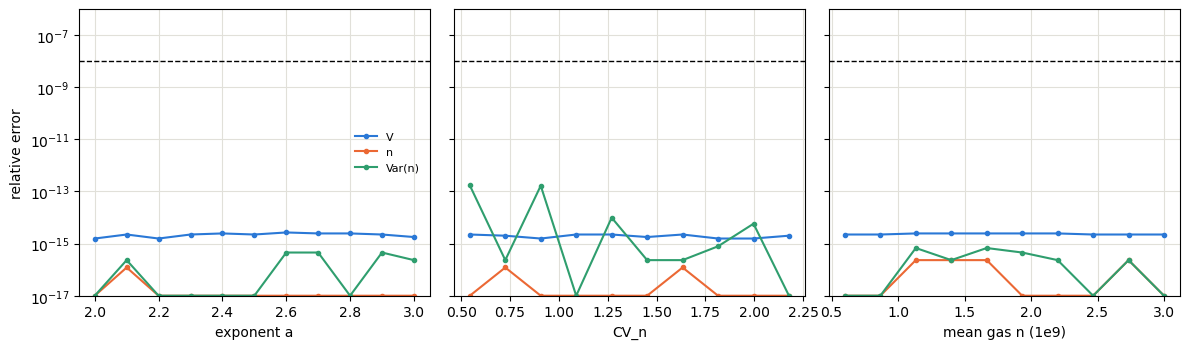

largest relative error over the three scans: 1.709743457922741e-13


In [88]:
def errors(n_mean, var_n, V_mean, a_):
    dp = build((3.0 * V_mean / (4.0 * np.pi)) ** (1.0 / 3.0), n_mean, var_n, T, a_)
    mp = moments(dp)
    return abs(mp["V"] / V_mean - 1), abs(mp["n"] / n_mean - 1), abs(mp["var_n"] / var_n - 1)

floor = 1e-17   # keeps exact zeros on the log axis
cv_in = np.sqrt(var_in) / n_in
scans = (
    ("exponent a",            np.linspace(2.0, 3.0, 11),            lambda x: errors(n_in, var_in, V_in, x)),
    ("CV_n",                  np.linspace(0.5, 2.0, 10) * cv_in, lambda x: errors(n_in, (x * n_in) ** 2, V_in, a)),
    ("mean gas n (1e9)",      np.linspace(0.6, 3.0, 10),            lambda x: errors(x * 1e9, (cv_in * x * 1e9) ** 2, V_in, a)),
)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax_, (label, xs, fn) in zip(ax, scans):
    e = np.array([fn(x) for x in xs]) + floor
    for k, (name, color) in enumerate((("V", "#2a78d6"), ("n", "#eb6834"), ("Var(n)", "#2f9e6e"))):
        ax_.semilogy(xs, e[:, k], "o-", ms=3, color=color, label=name)
    ax_.axhline(1e-8, color="k", ls="--", lw=1)
    ax_.set(xlabel=label, ylim=(1e-17, 1e-6))
    ax_.grid(True, color="#e1e0d9")
ax[0].set_ylabel("relative error")
ax[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()
print("largest relative error over the three scans:", max(np.max([fn(x) for x in xs]) for _, xs, fn in scans))

## Rupture per class on a heat-up
Rigid pores at fixed gas $n_i$ and volume $V_i$ (as option 2), $T$ from the base temperature up, $P_h$ constant. Class $i$ breaks when $p_i\ge P_{cr,i}=2\gamma/R_i+[\sigma^{cr}_{hbs}(1-\xi)+P_h]/\xi$ (J19 Eq. 22, $\sigma^{cr}_{hbs}=21$ MPa). Instantaneous, no relaxation time.
$D^*=\sum w_i[\text{broken}]$, $G^*=\sum w_in_i[\text{broken}]/\sum w_in_i$. The porosity $\xi$ is an input (the pore density is not part of the moments).

NB. The higher number of classes the lower the steps that we see in the plot.

a = 3.00: P_cr = 848..869 MPa,  p at 800 K = 209..209 MPa,  D(1700 K) = 0.000
a = 2.75: P_cr = 848..872 MPa,  p at 800 K = 134..501 MPa,  D(1700 K) = 0.000
a = 2.50: P_cr = 847..877 MPa,  p at 800 K = 84..2332 MPa,  D(1700 K) = 0.133


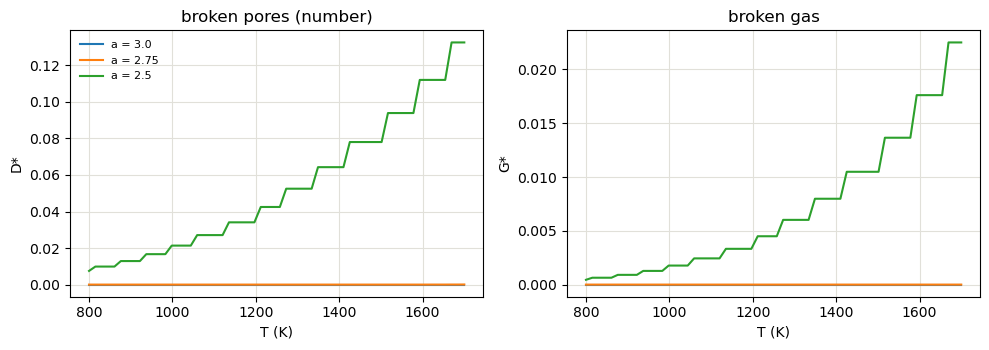

In [89]:
xi = 0.105          # (/) porosity, NFIR end of base irradiation (README L11)
sigma_cr = 21.0e6   # (Pa) [P] J19 Table 4
T_list = np.linspace(T, 1700.0, 60)

def heatup(dist, xi, Ph):
    D, G = [], []
    for Tk in T_list:
        p = pore_pressure(dist["n"], dist["V"], Tk)
        p_cr = 2.0 * GAMMA / dist["R"] + (sigma_cr * (1.0 - xi) + Ph) / xi
        b = p >= p_cr
        D.append(np.sum(dist["w"][b]))
        G.append(np.sum((dist["w"] * dist["n"])[b]) / np.sum(dist["w"] * dist["n"]))
    return np.array(D), np.array(G)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for a_ in (3.0, 2.75, 2.5):
    dist = build(R_V, n_in, var_in, T, a_)
    D, G = heatup(dist, xi, Ph)
    ax[0].plot(T_list, D, label=f"a = {a_}")
    ax[1].plot(T_list, G, label=f"a = {a_}")
    p_cr0 = 2.0 * GAMMA / dist["R"] + (sigma_cr * (1.0 - xi) + Ph) / xi
    print(f"a = {a_:4.2f}: P_cr = {p_cr0.min() / 1e6:.0f}..{p_cr0.max() / 1e6:.0f} MPa,  p at {T:.0f} K = {dist['p'].min() / 1e6:.0f}..{dist['p'].max() / 1e6:.0f} MPa,  D(1700 K) = {D[-1]:.3f}")
ax[0].set(xlabel="T (K)", ylabel="D*", title="broken pores (number)")
ax[1].set(xlabel="T (K)", ylabel="G*", title="broken gas")
for ax_ in ax:
    ax_.grid(True, color="#e1e0d9")
ax[0].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# Normalised representation for micromechanics
For the micromechanics only the **relative** sizes matter: $x_i=R_i/R_V$, the pressure relative to the mean, $p_i/\bar p$, and the weights $w_i$. In these variables the distribution depends on three dimensionless numbers only: the closure exponent $a$, the coefficient of variation $\mathrm{CV}_n=\sqrt{\mathrm{Var}(n)}/\bar n$ and the mean packing fraction $\bar\eta=\bar n\,v_{Xe}(T)/\bar V$ (section *Does the pressure distribution change with the mean radius?*). $R_V$ and $\bar p$ then only rescale the axes, and $T$ enters only through $\bar\eta$.

The dependence on $\bar\eta$ is not negligible. In the dilute limit ($\bar\eta\to0$, $Z\to1$) the shape is universal, $p_i/\bar p\propto x_i^{a-3}$; the table below gives the largest relative deviation from it over the central classes ($R_i/R_V$ within $\pm2s$ of the median, about 96 % of the pores) and over all classes. A single universal curve is a good approximation only for $\bar\eta\lesssim0.02$; at the packing fraction of the test case ($\bar\eta\approx0.19$) it is not.

a = 2.5, CV_n = 1.089, s = 0.3560; central classes: x in [0.41, 1.67], weight 0.957
  eta_bar  max dev, central  max dev, all   (relative to the dilute limit)
    0.020             0.058         0.124
    0.067             0.223         0.528
    0.194             0.977         3.590
    0.400             5.053         5.053


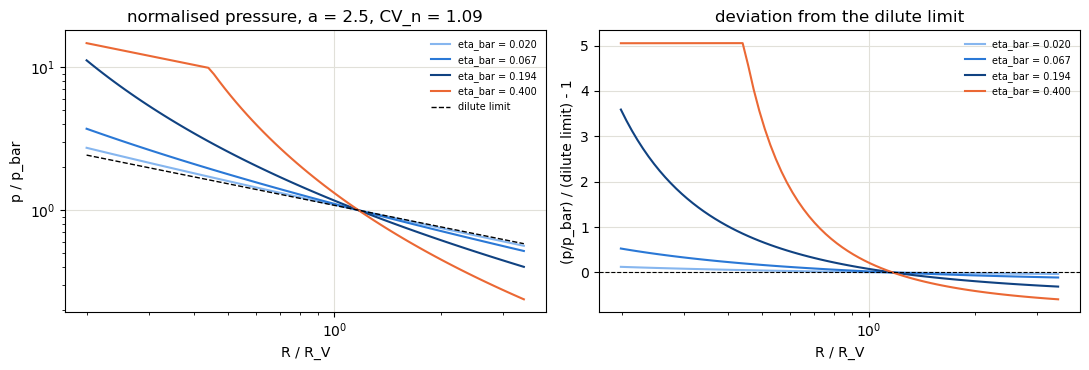

In [90]:
def normalised(a_, cv_n_, eta_bar, T_=T, R_V_=R_V):
    """Classes in relative variables for given (a, CV_n, eta_bar): x = R/R_V, p/p_bar, n/n_bar, V/V_bar, w.
    R_V_ and T_ only set the (irrelevant) scale: n_bar is chosen so that the mean packing fraction is eta_bar."""
    V_ = 4.0 / 3.0 * np.pi * R_V_**3
    n_ = eta_bar * V_ / xe_volume(T_)
    dd = build(R_V_, n_, (cv_n_ * n_) ** 2, T_, a_)
    p_bar_ = float(pore_pressure(n_, V_, T_))
    return {"x": dd["R"] / R_V_, "w": dd["w"], "p_rel": dd["p"] / p_bar_, "n_rel": dd["n"] / n_, "V_rel": dd["V"] / V_, "sigma": dd["sigma"]}

cv_n = np.sqrt(var_in) / n_in
eta_test = n_in * xe_volume(T) / V_in
etas = (1e-4, 0.02, 0.067, eta_test, 0.4)
ref = normalised(a, cv_n, etas[0])                     # dilute limit
central = (ref["x"] > np.exp(-2 * ref["sigma"]) * 0.83) & (ref["x"] < np.exp(2 * ref["sigma"]) * 0.83)
print(f"a = {a}, CV_n = {cv_n:.3f}, s = {ref['sigma']:.4f}; central classes: x in [{ref['x'][central].min():.2f}, {ref['x'][central].max():.2f}], weight {ref['w'][central].sum():.3f}")
print(f"{'eta_bar':>9s}{'max dev, central':>18s}{'max dev, all':>14s}   (relative to the dilute limit)")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for eta_, color in zip(etas[1:], ("#86b6ef", "#2a78d6", "#104281", "#eb6834")):
    nn = normalised(a, cv_n, eta_)
    dev = nn["p_rel"] / ref["p_rel"] - 1.0
    print(f"{eta_:9.3f}{np.max(np.abs(dev[central])):18.3f}{np.max(np.abs(dev)):14.3f}")
    ax[0].plot(nn["x"], nn["p_rel"], color=color, label=f"eta_bar = {eta_:.3f}")
    ax[1].plot(nn["x"], dev, color=color, label=f"eta_bar = {eta_:.3f}")
ax[0].plot(ref["x"], ref["p_rel"], "k--", lw=1, label="dilute limit")
ax[0].set(xlabel="R / R_V", ylabel="p / p_bar", title=f"normalised pressure, a = {a}, CV_n = {cv_n:.2f}", xscale="log", yscale="log")
ax[1].axhline(0.0, color="k", lw=0.8, ls="--")
ax[1].set(xlabel="R / R_V", ylabel="(p/p_bar) / (dilute limit) - 1", title="deviation from the dilute limit", xscale="log")
for ax_ in ax:
    ax_.grid(True, color="#e1e0d9"); ax_.legend(frameon=False, fontsize=7)
fig.tight_layout()
plt.show()

## Coverage of the parameter space 

| parameter | enters | through |
|---|---|---|
| $\mathrm{CV}_n$ | the radius distribution ($s$) | moments |
| $\bar\eta$ | the shape $p/\bar p$ | $Z(\eta)$ |
| $\xi$ | the geometry of the RVE | porosity |
| $P_h$, $\bar p$, $T$ | the loading and the material properties| linear superposition|


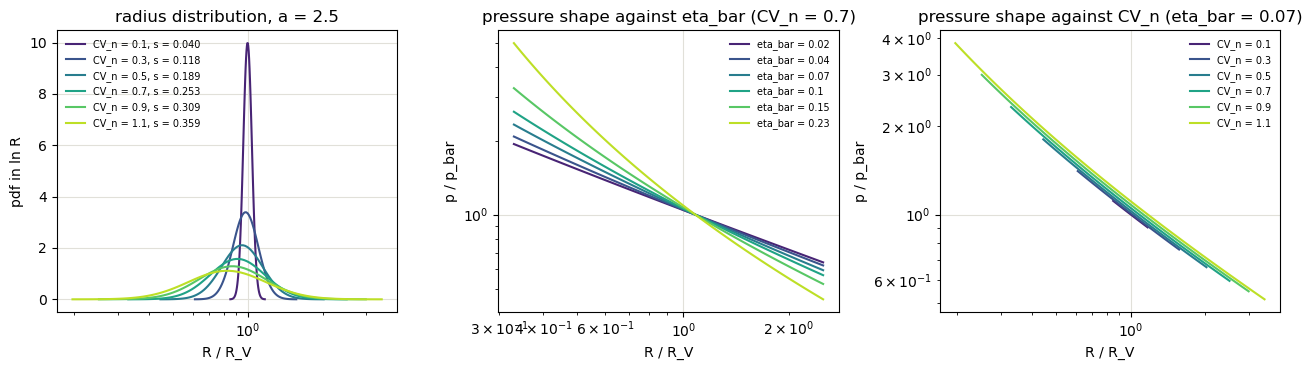

In [92]:
# grids to be covered; the closure exponent is the one of the inputs
A_CLOSURE = a
cv_ref, eta_ref = 0.7, 0.07
GRID_XI  = (0.03, 0.07, 0.11, 0.15, 0.20)
GRID_CV  = (0.1, 0.3, 0.5, 0.7, 0.9, 1.1)
GRID_ETA = (0.02, 0.04, 0.07, 0.10, 0.15, 0.23)

def cmap(k, n):
    return plt.cm.viridis(0.1 + 0.8 * k / max(n - 1, 1))

fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
for k, cv_ in enumerate(GRID_CV):                      # radius distribution against CV_n: depends on s only
    nn = normalised(A_CLOSURE, cv_, eta_ref)
    ax[0].plot(nn["x"], nn["w"] / np.gradient(np.log(nn["x"])), color=cmap(k, len(GRID_CV)), label=f"CV_n = {cv_}, s = {nn['sigma']:.3f}")
ax[0].set(xlabel="R / R_V", ylabel="pdf in ln R", title=f"radius distribution, a = {A_CLOSURE}", xscale="log")
for k, e_ in enumerate(GRID_ETA):                      # pressure shape against eta_bar
    nn = normalised(A_CLOSURE, cv_ref, e_)
    ax[1].plot(nn["x"], nn["p_rel"], color=cmap(k, len(GRID_ETA)), label=f"eta_bar = {e_}")
ax[1].set(xlabel="R / R_V", ylabel="p / p_bar", title=f"pressure shape against eta_bar (CV_n = {cv_ref})", xscale="log", yscale="log")
for k, cv_ in enumerate(GRID_CV):                      # pressure shape against CV_n
    nn = normalised(A_CLOSURE, cv_, eta_ref)
    ax[2].plot(nn["x"], nn["p_rel"], color=cmap(k, len(GRID_CV)), label=f"CV_n = {cv_}")
ax[2].set(xlabel="R / R_V", ylabel="p / p_bar", title=f"pressure shape against CV_n (eta_bar = {eta_ref})", xscale="log", yscale="log")
for ax_ in ax:
    ax_.grid(True, color="#e1e0d9"); ax_.legend(frameon=False, fontsize=7)
fig.tight_layout()
plt.show()

## Normalised against direct: do $\mathrm{CV}_n$ and $\bar\eta$ suffice?
Question: can SCIANTIX pass only $(\mathrm{CV}_n,\bar\eta)$, with $R_V$, $\bar n$, $T$ left out of the parameter space?
- **A.** Fixed $(\mathrm{CV}_n,\bar\eta)$, different $(R_V,T,\bar n)$ with $\bar n=\bar\eta\bar V/v_{Xe}(T)$: the direct classes (dots) lie on the normalised curve (line).
- **B.** Fixed $R_V$, $T$, $\mathrm{CV}_n$, only $\bar n$ varied: $\bar\eta$ changes and so does the shape; each direct curve coincides with the normalised one at its own $\bar\eta$.
- **C.** Random states in the SCIANTIX range, direct against normalised at the $(\mathrm{CV}_n,\bar\eta)$ of the state, and against the interpolation in the grid `GRID_CV` $\times$ `GRID_ETA` (bilinear in $\ln(p/\bar p)$ and in $\bar\eta$, $\mathrm{CV}_n$) [N].

A: max |direct / normalised - 1| = 4.0e-15
B: max |direct / normalised - 1| = 1.0e-14


C: normalised on the exact (CV_n, eta_bar): max rel. error 6.0e-15
C: grid interpolation (6 x 6 points): max 4.11e-02, median 4.17e-03


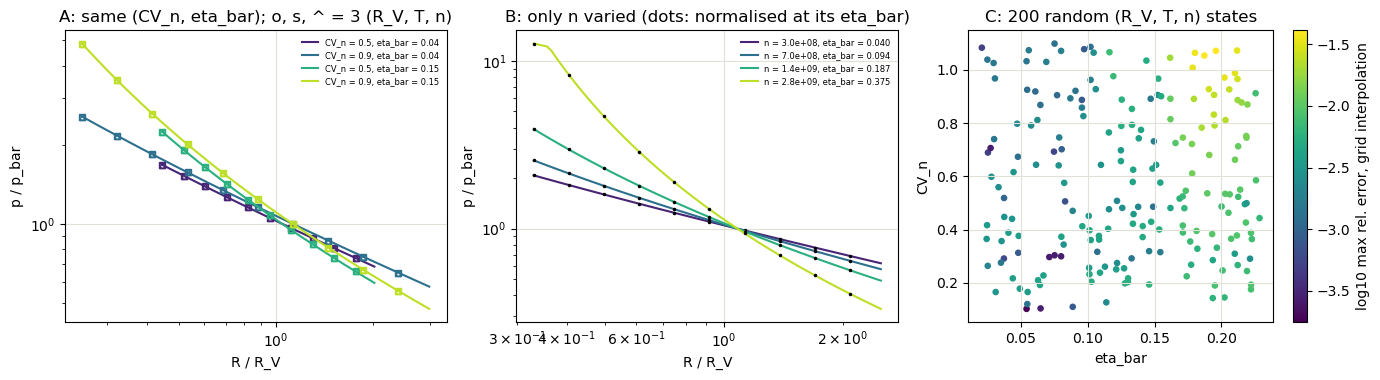

In [13]:
from scipy.interpolate import RegularGridInterpolator

def direct(R_V_, n_, cv_n_, T_, a_):
    """Classes built from dimensional values (R_V, n_bar, T): x = R/R_V, p/p_bar, eta_bar."""
    V_ = 4.0 / 3.0 * np.pi * R_V_**3
    dd = build(R_V_, n_, (cv_n_ * n_) ** 2, T_, a_)
    return dd["R"] / R_V_, dd["p"] / float(pore_pressure(n_, V_, T_)), n_ * xe_volume(T_) / V_

fig, ax = plt.subplots(1, 3, figsize=(14, 3.9))

# A: same (CV_n, eta_bar), different (R_V, T, n_bar)
combos = ((0.5, 0.04), (0.9, 0.04), (0.5, 0.15), (0.9, 0.15))
states = ((0.25e-6, 600.0), (0.40e-6, 1000.0), (0.80e-6, 1500.0))
errA = 0.0
for k, (cv_, eta_) in enumerate(combos):
    nn = normalised(a, cv_, eta_)
    ax[0].plot(nn["x"], nn["p_rel"], color=cmap(k, len(combos)), label=f"CV_n = {cv_}, eta_bar = {eta_}")
    for (RV_, T_), mk in zip(states, ("o", "s", "^")):
        n_ = eta_ * (4.0 / 3.0 * np.pi * RV_**3) / xe_volume(T_)
        x, y, _ = direct(RV_, n_, cv_, T_, a)
        errA = max(errA, np.max(np.abs(y / nn["p_rel"] - 1.0)))
        ax[0].plot(x[::8], y[::8], mk, ms=4, mfc="none", color=cmap(k, len(combos)))
ax[0].set(xlabel="R / R_V", ylabel="p / p_bar", xscale="log", yscale="log", title="A: same (CV_n, eta_bar); o, s, ^ = 3 (R_V, T, n)")
print(f"A: max |direct / normalised - 1| = {errA:.1e}")

# B: only n_bar varied
RV_b, T_b, cv_b = 0.35e-6, 800.0, 0.7
errB = 0.0
for k, n_ in enumerate((0.3e9, 0.7e9, 1.4e9, 2.8e9)):
    x, y, eta_ = direct(RV_b, n_, cv_b, T_b, a)
    nn = normalised(a, cv_b, eta_)
    errB = max(errB, np.max(np.abs(y / nn["p_rel"] - 1.0)))
    ax[1].plot(x, y, color=cmap(k, 4), label=f"n = {n_:.1e}, eta_bar = {eta_:.3f}")
    ax[1].plot(nn["x"][::8], nn["p_rel"][::8], "k.", ms=3)
ax[1].set(xlabel="R / R_V", ylabel="p / p_bar", xscale="log", yscale="log", title="B: only n varied (dots: normalised at its eta_bar)")
print(f"B: max |direct / normalised - 1| = {errB:.1e}")

# C: random states; normalised on the exact (CV_n, eta_bar) and interpolated in the grid
grid_lnp = np.array([[np.log(normalised(a, cv_, eta_)["p_rel"]) for eta_ in GRID_ETA] for cv_ in GRID_CV])   # (cv, eta, class)
interp = RegularGridInterpolator((GRID_CV, GRID_ETA), grid_lnp)
rng = np.random.default_rng(1)
ex, it, pts = [], [], []
while len(ex) < 200:
    RV_, T_, cv_ = rng.uniform(0.15e-6, 0.9e-6), rng.uniform(600.0, 1700.0), rng.uniform(GRID_CV[0], GRID_CV[-1])
    V_ = 4.0 / 3.0 * np.pi * RV_**3
    n_ = rng.uniform(0.02, 0.23) * V_ / xe_volume(T_)
    x, y, eta_ = direct(RV_, n_, cv_, T_, a)
    if not (GRID_ETA[0] <= eta_ <= GRID_ETA[-1]):
        continue
    ex.append(np.max(np.abs(y / normalised(a, cv_, eta_)["p_rel"] - 1.0)))
    it.append(np.max(np.abs(y / np.exp(interp((cv_, eta_))) - 1.0)))
    pts.append((cv_, eta_))
pts = np.array(pts)
sc = ax[2].scatter(pts[:, 1], pts[:, 0], c=np.log10(np.maximum(it, 1e-16)), cmap="viridis", s=14)
fig.colorbar(sc, ax=ax[2], label="log10 max rel. error, grid interpolation")
ax[2].set(xlabel="eta_bar", ylabel="CV_n", title="C: 200 random (R_V, T, n) states")
print(f"C: normalised on the exact (CV_n, eta_bar): max rel. error {max(ex):.1e}")
print(f"C: grid interpolation ({len(GRID_CV)} x {len(GRID_ETA)} points): max {max(it):.2e}, median {np.median(it):.2e}")
for ax_ in ax[:2]:
    ax_.grid(True, color="#e1e0d9"); ax_.legend(frameon=False, fontsize=6)
ax[2].grid(True, color="#e1e0d9")
fig.tight_layout()
plt.show()